In [1]:
import os
import sys
import random
import bentoml
import numpy as np
import pandas as pd
import pprint as pp
from pathlib import Path

# 현재 노트북이 있는 경로 기준으로 프로젝트 루트(recsys) 경로 계산
current_dir = (
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in globals()
    else os.getcwd()
)
project_root = os.path.abspath(os.path.join(current_dir, ".."))

# recsys 폴더를 sys.path에 추가
if project_root not in sys.path:
    sys.path.append(project_root)

from setup_env import setup_env

root_dir = setup_env()

from models.transformer.preprocess import SequenceGenerator
from utils.dataset.config import DatasetPath
from utils.dataset.plot import show_items
from models.transformer.model import Model
from utils.retriever.ann import build_index, search

device = "cpu"

[INFO] Font applied: NanumGothic


# Load Dataset

In [2]:
# 데이터셋 경로
dataset_dir = Path(root_dir).joinpath("data/dataset")
paths = DatasetPath(root_dir=dataset_dir, dataset_name="fashion")

df_item = pd.read_parquet(paths.item_metadata_path)
df_user_logs = pd.read_parquet(paths.user_logs_path)
df_user_logs.head()

,user_id,item_id,timestamp,action,age,gender,name,brand_name,price,discount_price,...,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,description
0,1,2925,2025-09-21 03:01:00,click,46,Women,Vogue Women Pink Sunglasses,vogue,4930.0,4437.0,...,Pink,Winter,2016,Casual,Accessories,Eyewear,Sunglasses,<UNK>,<UNK>,<p>This stylish range of vogue sunglasses are ...
1,1,2290,2025-09-21 03:02:00,click,46,Women,Idee Women Funky Eyewear Black Sunglasses,I DEE,1950.0,1755.0,...,Black,Winter,2016,Casual,Accessories,Eyewear,Sunglasses,<UNK>,<UNK>,"<p>High on style, this pair of sunglasses from..."
2,1,1287,2025-09-21 03:05:00,click,46,Women,Idee Women Funky Eyewear Black Sunglasses,I DEE,1450.0,1305.0,...,Black,Winter,2016,Casual,Accessories,Eyewear,Sunglasses,<UNK>,<UNK>,"<p>High on style, this pair of sunglasses from..."
3,1,7226,2025-09-21 03:04:00,click,46,Women,Miami Blues Women Sunglasses,Miami Blues,915.0,713.0,...,Purple,Winter,2016,Casual,Accessories,Eyewear,Sunglasses,<UNK>,<UNK>,<p>NA</p>
4,1,868,2025-09-21 03:17:00,click,46,Women,United Colors of Benetton Women Sunglass,United Colors of Benetton,3450.0,3105.0,...,Black,Winter,2016,Casual,Accessories,Eyewear,Sunglasses,<UNK>,<UNK>,"<p><span style=""color: #000000 font-family;"">..."


# Load Model

In [3]:
# 모델 저장 디렉토리 경로
seq_model_artifact = bentoml.models.get("transformer:latest")
reg_model_artifact = bentoml.models.get("regressor:latest")

seq_model_dir = Path(seq_model_artifact.path_of("artifact"))
reg_model_dir = Path(reg_model_artifact.path_of("artifact"))

# 모델 객체 초기화
model = Model(seq_model_dir=seq_model_dir, reg_model_dir=reg_model_dir)

/Users/hwangyungwan/miniforge3/envs/ds_p313/lib/python3.13/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


## Prediction Test

In [4]:
# 학습 데이터셋의 랜덤 유저를 추출하여 시퀀스 샘플 생성
user_id = random.choice(df_user_logs["user_id"].unique())
df_user_sample = df_user_logs[df_user_logs["user_id"] == user_id]
df_user_sample = df_user_sample.sort_values(by="user_id", ignore_index=True)

In [5]:
sequence_generator = SequenceGenerator(max_seq_len=model.seq_model_config["seq_len"])

feature_names = list(model.seq_model_config["feature_dims"].keys()) + ["item_id"]
target_names = list(model.seq_model_config["feature_dims"].keys())

df_seq_sample = sequence_generator.get_seq_dataframe(
    data=df_user_sample, feature_sequences=feature_names
)
df_seq_sample = df_seq_sample[df_seq_sample["seq_len"] == 5]
df_seq_sample

,user_id,user_rn,seq_len,mask,brand_name,gender,age_group,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,action,item_id,y_item_id
0,6737,1,5,"[0, 0, 0, 0, 0]","[New Hide, BULCHEE, Park Avenue, Jealous 21, S...","[Men, Men, Men, Women, Women]","[Adults-Men, Adults-Men, Adults-Men, Adults-Wo...","[Brown, Black, Brown, Purple, Pink]","[Summer, Summer, Summer, Summer, Summer]","[2013, 2013, 2012, 2012, 2012]","[Formal, Formal, Formal, Casual, Casual]","[Accessories, Accessories, Accessories, Appare...","[Belts, Belts, Belts, Topwear, Topwear]","[Belts, Belts, Belts, Tops, Tops]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[Formal, Formal, Formal, Casual, Casual]","[purchase, click, wishlist, click, click]","[6300, 3320, 255, 9347, 4353]","[3320, 255, 9347, 4353, 7297]"
1,6737,2,5,"[0, 0, 0, 0, 0]","[BULCHEE, New Hide, BULCHEE, Park Avenue, Jeal...","[Men, Men, Men, Men, Women]","[Adults-Men, Adults-Men, Adults-Men, Adults-Me...","[Brown, Brown, Black, Brown, Purple]","[Winter, Summer, Summer, Summer, Summer]","[2015, 2013, 2013, 2012, 2012]","[Casual, Formal, Formal, Formal, Casual]","[Accessories, Accessories, Accessories, Access...","[Wallets, Belts, Belts, Belts, Topwear]","[Wallets, Belts, Belts, Belts, Tops]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, Formal, Formal, Formal, Casual]","[click, purchase, click, wishlist, click]","[7171, 6300, 3320, 255, 9347]","[6300, 3320, 255, 9347, 4353]"
2,6737,3,5,"[0, 0, 0, 0, 0]","[Vero Moda, Arrow Woman, Mineral, ONLY, Vero M...","[Women, Women, Women, Women, Women]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[White, Pink, Green, White, Yellow]","[Summer, Summer, Summer, Summer, Summer]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Apparel, Apparel, Apparel, Apparel, Apparel]","[Topwear, Topwear, Topwear, Topwear, Topwear]","[Tops, Tops, Tops, Tops, Tops]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[Casual, Casual, Casual, Casual, Casual]","[click, click, click, click, click]","[7550, 353, 6529, 5730, 7914]","[353, 6529, 5730, 7914, 5257]"
3,6737,4,5,"[0, 0, 0, 0, 0]","[Fossil, BULCHEE, New Hide, BULCHEE, Park Avenue]","[Men, Men, Men, Men, Men]","[Adults-Men, Adults-Men, Adults-Men, Adults-Me...","[Brown, Brown, Brown, Black, Brown]","[Winter, Winter, Summer, Summer, Summer]","[2016, 2015, 2013, 2013, 2012]","[Casual, Casual, Formal, Formal, Formal]","[Accessories, Accessories, Accessories, Access...","[Wallets, Wallets, Belts, Belts, Belts]","[Wallets, Wallets, Belts, Belts, Belts]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, Formal, Formal, Formal]","[click, click, purchase, click, wishlist]","[5503, 7171, 6300, 3320, 255]","[7171, 6300, 3320, 255, 9347]"
5,6737,6,5,"[0, 0, 0, 0, 0]","[Tonga, Vero Moda, Arrow Woman, Mineral, ONLY]","[Women, Women, Women, Women, Women]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[Black, White, Pink, Green, White]","[Summer, Summer, Summer, Summer, Summer]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Apparel, Apparel, Apparel, Apparel, Apparel]","[Topwear, Topwear, Topwear, Topwear, Topwear]","[Tops, Tops, Tops, Tops, Tops]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[Casual, Casual, Casual, Casual, Casual]","[click, click, click, click, click]","[7297, 7550, 353, 6529, 5730]","[7550, 353, 6529, 5730, 7914]"
6,6737,7,5,"[0, 0, 0, 0, 0]","[Sepia, Tonga, Vero Moda, Arrow Woman, Mineral]","[Women, Women, Women, Women, Women]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[Pink, Black, White, Pink, Green]","[Summer, Summer, Summer, Summer, Summer]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Apparel, Apparel, Apparel, Apparel, Apparel]","[Topwear, Topwear, Topwear, Topwear, Topwear]","[Tops, Tops, Tops, Tops, Tops]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[Casual, Casual, Casual, Casual, Casual]","[click, click, click, click, click]","[4353, 7297, 7550, 353, 6529]","[7297, 7550, 353, 6529, 5730

In [6]:
seq_sample = df_seq_sample.sample(1).to_dict(orient="records")[0]
seq_sample

{'user_id': 6737,
 'user_rn': 14,
 'seq_len': 5,
 'mask': [0, 0, 0, 0, 0],
 'brand_name': ['Nyk', 'Lino Perros', 'Baggit', 'BULCHEE', 'Fastrack'],
 'gender': ['Women', 'Women', 'Women', 'Women', 'Men'],
 'age_group': ['Adults-Women',
  'Adults-Women',
  'Adults-Women',
  'Adults-Women',
  'Adults-Men'],
 'base_color': ['Grey', 'Purple', 'Bronze', 'Black', 'Brown'],
 'season': ['Summer', 'Summer', 'Summer', 'Summer', 'Winter'],
 'year': ['2016', '2012', '2012', '2013', '2016'],
 'usage': ['Casual', 'Casual', 'Casual', 'Casual', 'Casual'],
 'master_category': ['Accessories',
  'Accessories',
  'Accessories',
  'Accessories',
  'Accessories'],
 'sub_category': ['Wallets', 'Wallets', 'Wallets', 'Wallets', 'Wallets'],
 'article_type': ['Wallets', 'Wallets', 'Wallets', 'Wallets', 'Wallets'],
 'fit': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'occasion': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'action': ['purchase', 'click', 'wishlist', 'click', 'click'],
 'item_id': [1583, 6189,

In [7]:
inputs = {}
for k in model.seq_model_config["feature_dims"].keys():
    inputs[k] = seq_sample[k]

pp.pprint(inputs)

{'action': ['purchase', 'click', 'wishlist', 'click', 'click'],
 'age_group': ['Adults-Women',
               'Adults-Women',
               'Adults-Women',
               'Adults-Women',
               'Adults-Men'],
 'article_type': ['Wallets', 'Wallets', 'Wallets', 'Wallets', 'Wallets'],
 'base_color': ['Grey', 'Purple', 'Bronze', 'Black', 'Brown'],
 'brand_name': ['Nyk', 'Lino Perros', 'Baggit', 'BULCHEE', 'Fastrack'],
 'fit': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'gender': ['Women', 'Women', 'Women', 'Women', 'Men'],
 'master_category': ['Accessories',
                     'Accessories',
                     'Accessories',
                     'Accessories',
                     'Accessories'],
 'occasion': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'season': ['Summer', 'Summer', 'Summer', 'Summer', 'Winter'],
 'sub_category': ['Wallets', 'Wallets', 'Wallets', 'Wallets', 'Wallets'],
 'usage': ['Casual', 'Casual', 'Casual', 'Casual', 'Casual'],
 'year': ['2016', '201

In [8]:
# 예시 입력: user_id와 시퀀스
body = [{"user_id": 123, "inputs": inputs}]

# Model.predict 호출 -> Transformer + Projection 결과 생성
prediction = model.predict(body)[0]
# pp.pprint(prediction)
# 출력: {"outputs": feature별 예측 값, "seq_vector": [...], "item_vector": [...]}

# Recommendation

In [9]:
# 이미지 기반 아이템 벡터 로드
df_image_vectors = pd.read_parquet(paths.image_vectors_path)

# text_vectors: (num_items, dim) numpy float32 배열
image_vectors = np.array(df_image_vectors["image_vector"].tolist())
image_vectors = np.array(image_vectors).astype(np.float32)

# {item index: item_id} 매핑
# (`df_text_vectors.index는` row index이므로 range(0..N-1)로 반환함)
item_id_maps = dict(zip(df_image_vectors["item_id"].index, df_image_vectors["item_id"]))

In [10]:
# 아이템 벡터 ANN 인덱스 생성
item_index = build_index(image_vectors)

In [11]:
# projection 모델에서 뽑은 item vector
query_vector = np.array(prediction["item_vector"])

# 아이템 벡터 인덱스에 질의한 결과 획득
result = search(query_vector, item_index, top_k=30)

# 추천 아이템 Index (원본 ID가 아닌 별도의 인덱스)
item_indies = list(result.keys())

# 추천 아이템 ID 재매핑
recommendation = {}
for i in item_indies:
    # 원본 ID로 매핑
    item_id = item_id_maps[i]
    recommendation[item_id] = result[i]

recommendation

{3781: 0.3362162113189697,
 8119: 0.3358442783355713,
 7225: 0.3355441093444824,
 508: 0.3323109745979309,
 1210: 0.33038485050201416,
 2757: 0.3301481604576111,
 3495: 0.33001160621643066,
 977: 0.3240266442298889,
 7465: 0.3201064467430115,
 641: 0.31961071491241455,
 2460: 0.31927406787872314,
 4097: 0.3172297477722168,
 657: 0.31626951694488525,
 1995: 0.314200222492218,
 8670: 0.3134395480155945,
 5611: 0.3129267692565918,
 9650: 0.3115013837814331,
 4707: 0.30761170387268066,
 5009: 0.30505985021591187,
 9966: 0.3049750328063965,
 2337: 0.3049119710922241,
 1753: 0.3040653467178345,
 9962: 0.3035935163497925,
 2707: 0.3031558394432068,
 2476: 0.3028970956802368,
 5766: 0.3024122714996338,
 6492: 0.3015376329421997,
 684: 0.3000548481941223,
 1363: 0.2999284267425537,
 3076: 0.299504816532135}

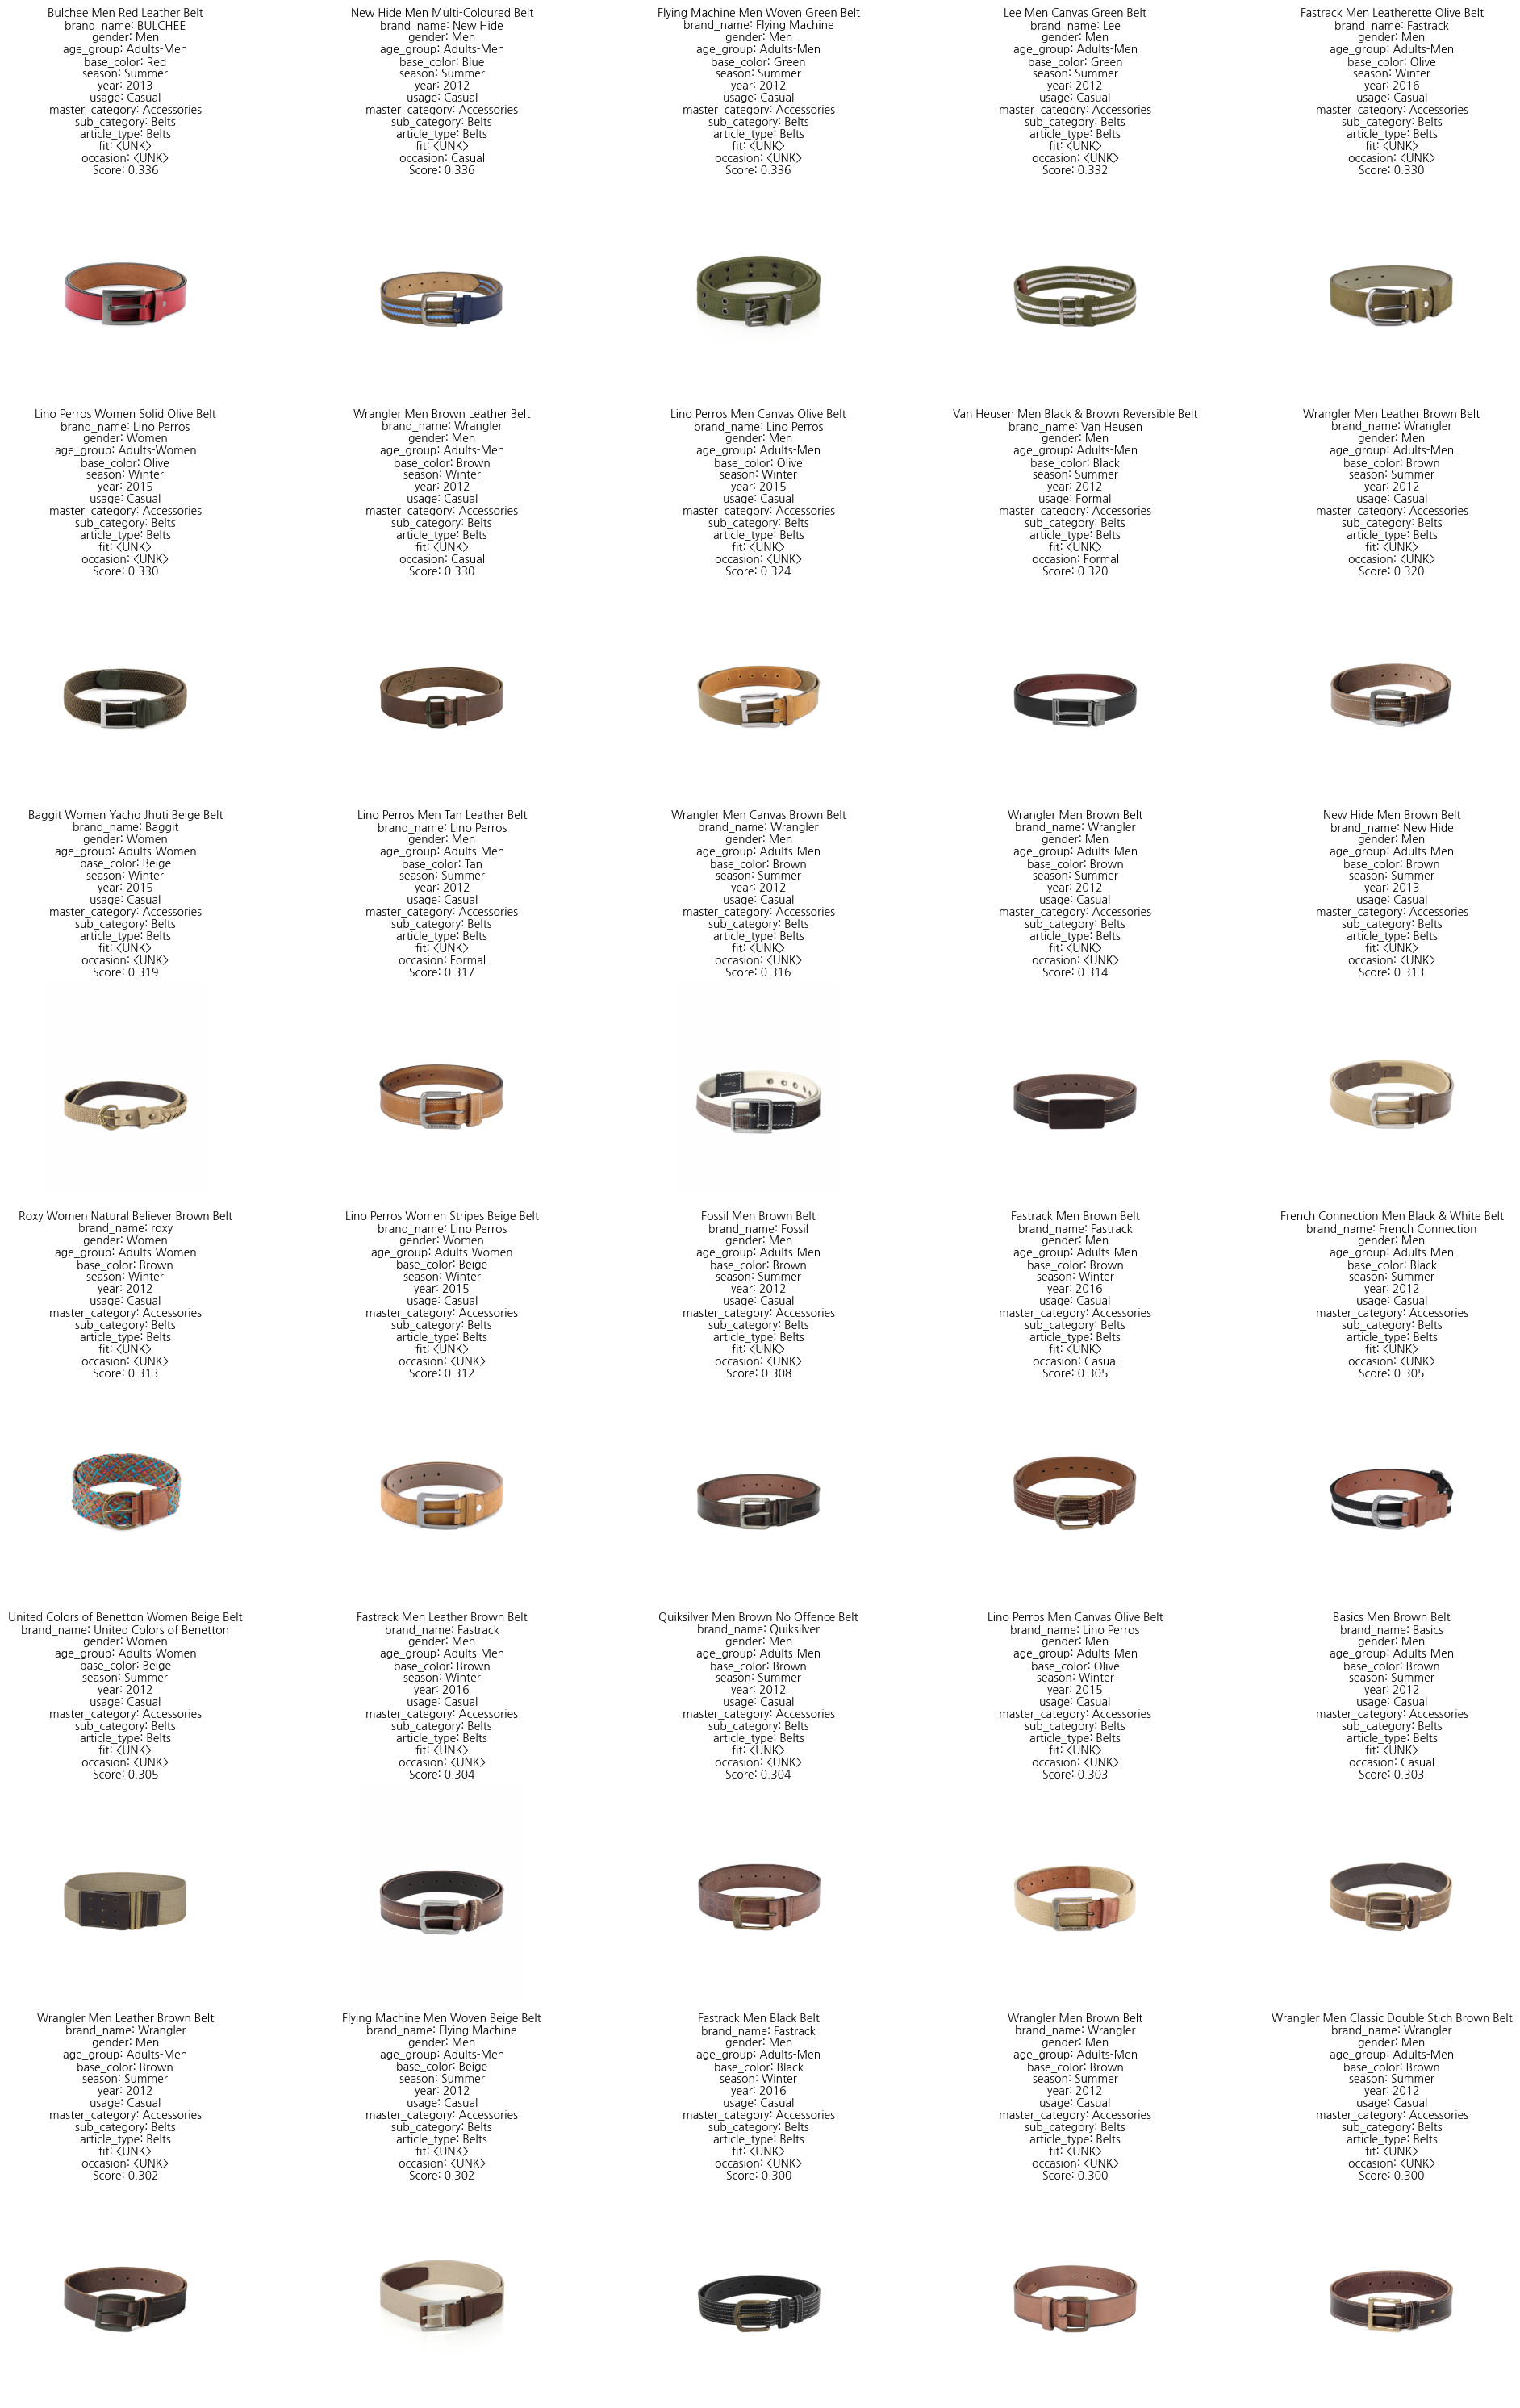

In [12]:
# 추천 아이템 후보군 상세 보기
show_items(
    item_ids=list(recommendation.keys()),
    df_item=df_item,
    attributes=tuple(model.seq_model_config["feature_dims"].keys()),
    scores=list(recommendation.values()),
    image_dir=paths.dataset_dir.joinpath("images"),
)